In [43]:
!pip install u8darts[torch]

In [44]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
import numpy as np
from sklearn.model_selection import ParameterGrid

from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel

In [45]:
df: pd.DataFrame = pd.read_csv("nyc_data.csv", index_col="Date", parse_dates=True)
df.head()

,Demand,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574
2015-01-03,754.117039,0,0,0,7.23,162.700
2015-01-04,622.252774,0,0,0,10.96,160.281
2015-01-05,785.373319,0,0,0,6.92,51.077


In [46]:
df.index.freq = "D"
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', name='Date', length=2192, freq='D')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2192 entries, 2015-01-01 to 2020-12-31
Freq: D
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Demand        2192 non-null   float64
 1   Easter        2192 non-null   int64  
 2   Thanksgiving  2192 non-null   int64  
 3   Christmas     2192 non-null   int64  
 4   Temperature   2192 non-null   float64
 5   Marketing     2192 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 119.9 KB


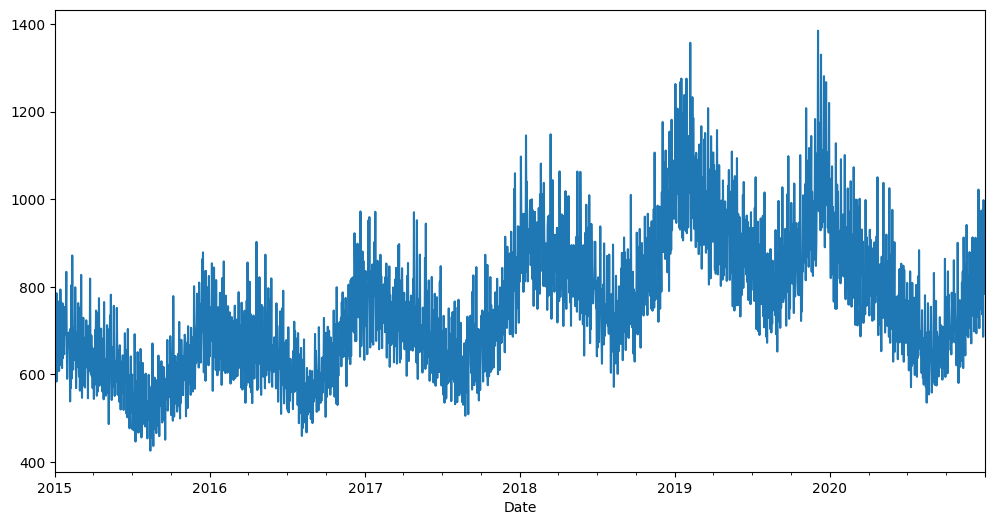

In [48]:
df = df.rename(columns={"Demand": "y"})
df["y"].plot(figsize=(12, 6))
plt.show()

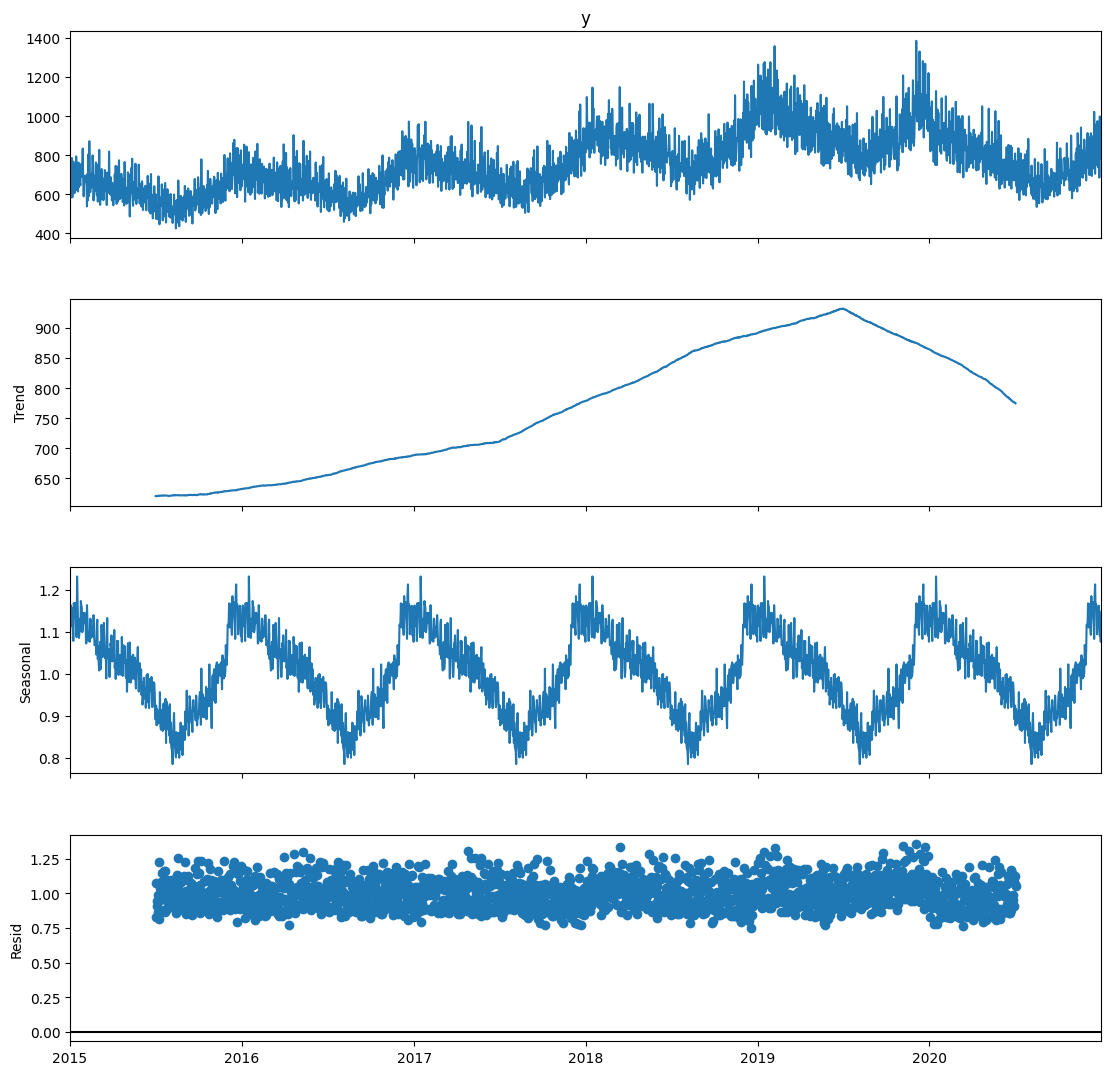

In [49]:
seas_dec = seasonal_decompose(df["y"], model="mul", period=365)

fig = seas_dec.plot()
fig.set_size_inches(12, 12)
plt.show()

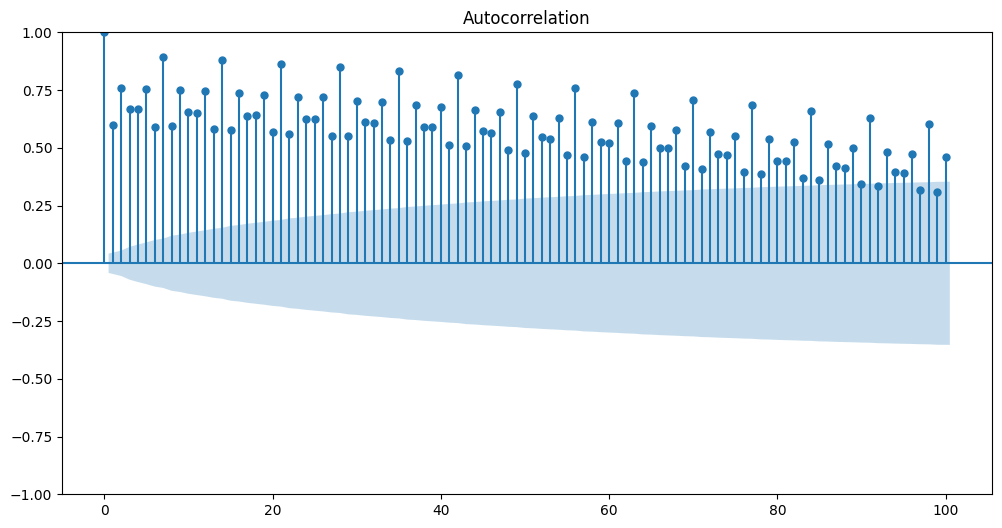

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df["y"], lags=100, ax=ax)
plt.show()

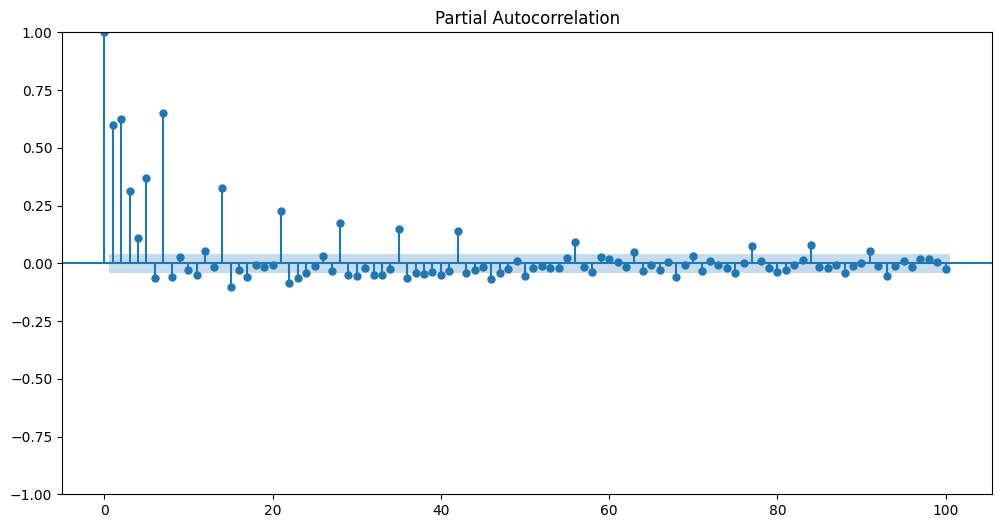

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(df["y"], lags=100, ax=ax)
plt.show()

In [52]:
series = TimeSeries.from_series(df["y"])
covariates = TimeSeries.from_dataframe(df.iloc[:, 1:])
covariates

,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,
2015-01-01,0.0,0.0,0.0,3.68,41.305
2015-01-02,0.0,0.0,0.0,4.73,131.574
2015-01-03,0.0,0.0,0.0,7.23,162.700
2015-01-04,0.0,0.0,0.0,10.96,160.281
2015-01-05,0.0,0.0,0.0,6.92,51.077
...,...,...,...,...,...
2020-12-27,0.0,0.0,0.0,2.89,38.674
2020-12-28,0.0,0.0,0.0,8.83,166.712
2020-12-29,0.0,0.0,0.0,3.48,161.865


In [53]:
# Create the time variables
year = datetime_attribute_timeseries(series, attribute="year", one_hot=False)
month = datetime_attribute_timeseries(series, attribute="month", one_hot=False)
weekday = datetime_attribute_timeseries(series, attribute="weekday", one_hot=False)

In [54]:
# Prepare the scalers
series_scaler = Scaler()
covariates_scaler = Scaler()

series_scaled = series_scaler.fit_transform(series=series)

In [55]:
# stack the time variables to the covariates
for var in [year, month, weekday]:
    covariates = covariates.stack(var)

In [56]:
covariates = covariates_scaler.fit_transform(covariates)

In [57]:
forecasting_horizon = 31
input_chunk_length = 46  # deve essere più grande del forecasting horizon

In [58]:
# LSTM building (RNN)

model = RNNModel(
    model="LSTM",
    input_chunk_length=input_chunk_length,
    hidden_dim=25,
    n_rnn_layers=2,
    dropout=0,
    training_length=input_chunk_length + forecasting_horizon,
    n_epochs=10,
    random_state=1502,
    optimizer_kwargs={"lr": 0.03},
    # pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]}, # solo se è abilitata gpu
)

In [59]:
model.fit(series_scaled, future_covariates=covariates, verbose=True)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 8.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
8.8 K     Trainable params
0         Non-trainable params
8.8 K     Total params
0.035     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=25, n_rnn_layers=2, dropout=0, training_length=77, input_chunk_length=46, n_epochs=10, random_state=1502, optimizer_kwargs={'lr': 0.03})

In [60]:
# Configs
start = df.shape[0]-180
stride = int(forecasting_horizon/2 )# come lo step tra una predizione e l'altra, numero di salti tra una pred e la consecutiva

stride



15

In [61]:
# Define the CV parameters
cv = model.historical_forecasts(series=series_scaled,
                               future_covariates=covariates,
                               start=start,
                               stride=stride,
                               retrain = True,
                               last_points_only=False,
                               verbose=True,
                               forecast_horizon=forecasting_horizon
                               )

historical forecasts:   0%|          | 0/10 [00:00<?, ?it/s]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 8.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
8.8 K     Trainable params
0         Non-trainable params
8.8 K     Total params

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

historical forecasts:  10%|█         | 1/10 [00:39<05:59, 39.94s/it]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 8.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
8.8 K     Trainable params
0         Non-trainable params
8.8 K     Tota

...

historical forecasts:  90%|█████████ | 9/10 [06:19<00:42, 42.88s/it]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 8.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
8.8 K     Trainable params
0         Non-trainable params
8.8 K     Tota

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

historical forecasts: 100%|██████████| 10/10 [07:02<00:00, 42.25s/it]


In [62]:
rmse_cv = []

for i in range(len(cv)):
  predictions = TimeSeries.to_series(series_scaler.inverse_transform(cv[0]))
  start_cv= predictions.index.min()
  end_cv= predictions.index.max()

  actuals= df.y[start_cv:end_cv]
  rmse=root_mean_squared_error(actuals,predictions)
  rmse_cv.append(rmse)

print(f"The RMSE is {np.mean(rmse_cv):.2f}")

The RMSE is 51.66


In [ ]:
grid = list(ParameterGrid(param_grid))

rmse_list = []

for params in grid:

    model = RNNModel(
        model="LSTM",
        input_chunk_length=params["input_chunk_length"],
        hidden_dim=params["hidden_dim"],
        n_rnn_layers=params["n_rnn_layers"],
        dropout=params["dropout"],
        training_length=params["training_length"],
        n_epochs=params["n_epochs"],
        random_state=1502,
        optimizer_kwargs={"lr": params["lr"]},
    )

    cv = model.historical_forecasts(
        series=series_scaled,
        future_covariates=covariates,
        start=start,
        stride=stride,
        retrain=True,
        last_points_only=False,
        verbose=True,
        forecast_horizon=forecasting_horizon
    )

    rmse_cv = []

    for i in range(len(cv)):

        predictions = TimeSeries.to_series(
            series_scaler.inverse_transform(cv[i])
        )

        start_cv = predictions.index.min()
        end_cv = predictions.index.max()

        actuals = df.y[start_cv:end_cv]

        rmse = root_mean_squared_error(actuals, predictions)

        rmse_cv.append(rmse)

    rmse_list.append(np.mean(rmse_cv))



historical forecasts:   0%|          | 0/10 [00:00<?, ?it/s]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 840    | train
6 | V               | Linear           | 11     | train
-------------------------------------------------------------
851       Trainable params
0         Non-trainable params
851       Total params

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

historical forecasts:  10%|█         | 1/10 [00:10<01:33, 10.41s/it]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 840    | train
6 | V               | Linear           | 11     | train
-------------------------------------------------------------
851       Trainable params
0         Non-trainable params
851       Tota

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

historical forecasts:  90%|█████████ | 9/10 [05:54<00:40, 40.18s/it]INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 1.7 K  | train
6 | V               | Linear           | 11     | train
-------------------------------------------------------------
1.7 K     Trainable params
0         Non-trainable params
1.7 K     Tota

Training: |          | 0/? [00:00<?, ?it/s]